# Stage 2 — Model Building & Validation
### Capstone Project: Analysing Insurance Claims for SafeDrive Insurance Ltd.

**Notebook:** `ml_model_building_and_validation.ipynb`

This notebook covers Tasks 2.1–2.3 of the capstone:
1. Prepare the modelling dataset (train/test split, leakage prevention, scaling)
2. Build and validate a baseline logistic regression model, after checking its key assumptions
3. Summarise model findings (key predictors, feature impacts, strengths, weaknesses)

**Input:** `cleaned_dataset.csv` (produced in Stage 1).

## Task 2.1 — Prepare the Modelling Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

df = pd.read_csv('cleaned_dataset.csv')
print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

# One-hot columns were written out as booleans — convert to int for modelling
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)
print(f"Converted {len(bool_cols)} boolean dummy columns to 0/1 integers")

Loaded cleaned dataset: 58,592 rows x 51 columns
Converted 21 boolean dummy columns to 0/1 integers


### Leakage check

`policy_id` is a unique record identifier with no predictive value, so it is dropped rather than
used as a feature. There is no field in this dataset that is only known *after* a claim is filed
(e.g. no `claim_amount`, `claim_date`, or settlement-related column) — every remaining column is
information available to underwriting **at policy issuance**, so there is no target-leakage risk
in the feature set.

In [2]:
X = df.drop(columns=['policy_id', 'is_claim'])
y = df['is_claim']

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(4) * 100}")
print(f"\nFeature columns used:\n{X.columns.tolist()}")

Feature matrix: (58592, 49)
Target distribution:
is_claim
0    93.6
1     6.4
Name: proportion, dtype: float64

Feature columns used:
['policy_tenure', 'age_of_car', 'population_density', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'torque_rpm', 'height_log', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_Diesel', 'fuel_type_Petrol', 'rear_brakes_type_Drum', 'transmission_type_Manual', 'steering_type_Manual', 'steering_type_Power', 'make_2', 'make_3', 'make_4', 'make_5', 'area_cluster_freq', 'model_freq', 'engine_type_freq', 'low_safety_high_exposure_flag', 'vehicle_age_band_Medium', 'vehicle_age_band

### Removing exactly-redundant dummy columns

The Stage 1 VIF check only screened continuous features. Once the one-hot/frequency-encoded
categorical columns are included, several are **perfectly (or near-perfectly) correlated** with
each other — e.g. `is_tpms`, `segment_C2` and `make_3` are identical indicator columns in this
data, because a vehicle's `model` deterministically fixes its `make`, `segment` and equipment
flags. Feeding perfectly collinear columns into an unregularized logistic regression produces a
singular information matrix, so one column from each perfectly-correlated pair (|correlation| >
0.99) is dropped before modelling. These are structural, deterministic duplicates (not statistical
noise), so removing them ahead of the train/test split does not introduce any leakage.

In [3]:
corr_matrix = X.astype(float).corr().abs()
kept_cols, redundant_cols = [], []
for c in X.columns:
    if any(corr_matrix.loc[c, k] > 0.99 for k in kept_cols):
        redundant_cols.append(c)
    else:
        kept_cols.append(c)

print(f"Dropping {len(redundant_cols)} exactly-redundant columns:")
print(redundant_cols)

X = X[kept_cols]
print(f"\nFeature matrix after redundancy removal: {X.shape}")

Dropping 11 exactly-redundant columns:
['is_rear_window_wiper', 'is_rear_window_washer', 'is_central_locking', 'is_ecw', 'segment_C2', 'segment_Utility', 'rear_brakes_type_Drum', 'steering_type_Manual', 'make_2', 'make_3', 'engine_type_freq']

Feature matrix after redundancy removal: (58592, 38)


In [4]:
# 80/20 train-test split, stratified on the target to preserve the ~6.4% claim rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, claim rate: {y_train.mean()*100:.2f}%")
print(f"Test shape:  {X_test.shape}, claim rate: {y_test.mean()*100:.2f}%")

Train shape: (46873, 38), claim rate: 6.40%
Test shape:  (11719, 38), claim rate: 6.40%


### Scaling — fit on train only

Continuous numeric features are standardised with `StandardScaler`. In line with leakage
prevention, the scaler is **fit only on the training data** and then used to *transform* both the
training and test sets with those same fitted parameters — the test set never influences the
scaling parameters. Binary/dummy (0/1) columns are passed through unscaled, since standardising a
binary indicator does not add value and would only make coefficients harder to interpret.

In [5]:
continuous_candidates = ['policy_tenure', 'age_of_car', 'population_density', 'torque_rpm',
                         'height_log', 'airbags', 'ncap_rating', 'area_cluster_freq',
                         'model_freq', 'engine_type_freq']
continuous_features = [c for c in continuous_candidates if c in X_train.columns]
binary_features = [c for c in X.columns if c not in continuous_features]

preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), continuous_features)],
    remainder='passthrough'
)

# Fit on train only
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Recover a clean, ordered column list (ColumnTransformer puts scaled cols first, then passthrough)
final_columns = continuous_features + binary_features
X_train_scaled = pd.DataFrame(X_train_transformed, columns=final_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_transformed, columns=final_columns, index=X_test.index)

print("Scaling complete (fit on train, applied to train & test).")
X_train_scaled[continuous_features].describe().round(2)

Scaling complete (fit on train, applied to train & test).


,policy_tenure,age_of_car,population_density,torque_rpm,height_log,airbags,ncap_rating,area_cluster_freq,model_freq
count,46873.00,46873.00,46873.00,46873.00,46873.00,46873.00,46873.00,46873.00,46873.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.47,-1.25,-1.17,-2.45,-1.01,-1.17,-1.27,-1.44,-2.05
25%,-0.97,-0.89,-0.78,-1.08,-1.01,-0.62,-1.27,-0.76,-1.33
50%,-0.09,-0.16,-0.60,-0.04,-0.28,-0.62,0.17,-0.10,0.51
75%,1.03,0.74,0.60,1.19,1.05,1.56,0.89,0.18,0.74
max,1.89,3.19,2.67,1.19,3.24,1.56,2.33,1.59,0.74


## Task 2.2 — Build and Validate the Baseline Model

### Checking logistic regression assumptions

**1. Independence of observations** — each row in the dataset represents one unique policyholder's
policy record (`policy_id` was confirmed unique with no duplicates in Stage 1, and there is no
repeated-measures or time-series structure — each policyholder contributes exactly one row). There
is no grouping/clustering (e.g. multiple policies per household) documented in the data dictionary,
so independent observations is a reasonable assumption here.

**2. Linearity of the log-odds** — checked for each continuous predictor using the **Box–Tidwell
test**: for each continuous feature `x`, a term `x * ln(x)` is added to a logistic regression
alongside `x`; a statistically significant coefficient on the interaction term indicates the
log-odds relationship is **not** linear in that predictor.

In [6]:
box_tidwell_candidates = ['policy_tenure', 'age_of_car', 'population_density',
                          'torque_rpm', 'height_log', 'area_cluster_freq',
                          'model_freq', 'engine_type_freq']
box_tidwell_features = [c for c in box_tidwell_candidates if c in X_train.columns]

bt_results = []
eps = 1e-6  # guard against log(0) for features with a zero minimum (e.g. age_of_car)

for feat in box_tidwell_features:
    x = X_train[feat].astype(float) + eps
    log_x = np.log(x)
    interaction = x * log_x

    X_bt = pd.DataFrame({feat: x, f'{feat}_x_ln{feat}': interaction})
    X_bt = sm.add_constant(X_bt)
    model_bt = sm.Logit(y_train.values, X_bt).fit(disp=0)

    p_value = model_bt.pvalues[f'{feat}_x_ln{feat}']
    if np.isnan(p_value):
        verdict = 'Undetermined (model did not converge cleanly - narrow feature range)'
    elif p_value >= 0.05:
        verdict = 'Yes'
    else:
        verdict = 'No (violated)'
    bt_results.append({'feature': feat, 'interaction_p_value': round(p_value, 4) if not np.isnan(p_value) else np.nan,
                        'linear_in_log_odds': verdict})

bt_df = pd.DataFrame(bt_results)
print(bt_df.to_string(index=False))

           feature  interaction_p_value                                                   linear_in_log_odds
     policy_tenure               0.0000                                                        No (violated)
        age_of_car               0.2389                                                                  Yes
population_density               0.0044                                                        No (violated)
        torque_rpm               0.2368                                                                  Yes
        height_log                  NaN Undetermined (model did not converge cleanly - narrow feature range)
 area_cluster_freq               0.3226                                                                  Yes
        model_freq               0.8296                                                                  Yes


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


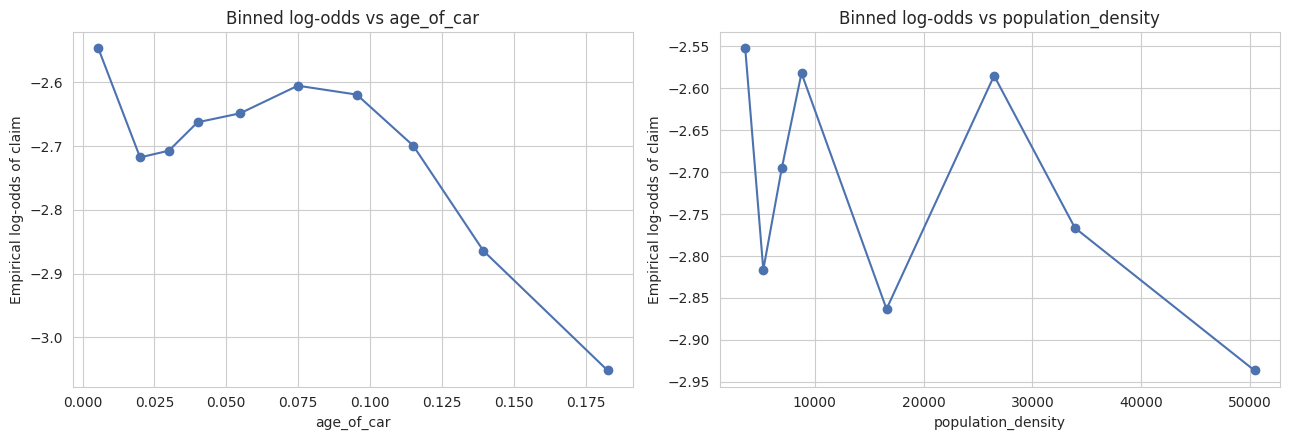


Where the Box-Tidwell test flags a violation, the corresponding feature's relationship with the log-odds is non-linear — this is noted as a limitation/area for improvement in Task 2.3 (e.g. a candidate for binning or a polynomial/spline term in a future iteration), rather than a reason to abandon logistic regression as the baseline.


In [7]:
# Visual check: binned empirical log-odds vs predictor value, for the two clearest business drivers
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, feat in zip(axes, ['age_of_car', 'population_density']):
    tmp = pd.DataFrame({feat: X_train[feat], 'is_claim': y_train})
    tmp['bin'] = pd.qcut(tmp[feat], q=10, duplicates='drop')
    binned = tmp.groupby('bin', observed=True).agg(mean_x=(feat, 'mean'), claim_rate=('is_claim', 'mean'))
    binned['log_odds'] = np.log(binned['claim_rate'] / (1 - binned['claim_rate']))
    ax.plot(binned['mean_x'], binned['log_odds'], marker='o', color='#4C72B0')
    ax.set_xlabel(feat)
    ax.set_ylabel('Empirical log-odds of claim')
    ax.set_title(f'Binned log-odds vs {feat}')

plt.tight_layout()
plt.show()

print("\nWhere the Box-Tidwell test flags a violation, the corresponding feature's relationship"
      " with the log-odds is non-linear — this is noted as a limitation/area for improvement in"
      " Task 2.3 (e.g. a candidate for binning or a polynomial/spline term in a future iteration),"
      " rather than a reason to abandon logistic regression as the baseline.")

### Fitting the baseline model

Even after removing exact duplicate dummy columns above, the vehicle-attribute one-hot/frequency
features remain **structurally rank-deficient** — vehicle `model` still determines most other
vehicle columns through combinations of several features at once (not just simple pairs), so an
unregularized statsmodels `Logit` fit on the full feature set hits a singular information matrix
and cannot converge. Given this, a single **scikit-learn `LogisticRegression`** with
`class_weight='balanced'` and its default L2 (ridge) penalty is used for **both** prediction and
interpretation — L2 regularization is numerically stable under collinearity (no matrix inversion of
a singular matrix is required), which is exactly the property needed here, at the cost of not
providing classical p-values.

A 5-fold **stratified cross-validation** on the training set is run first, to check the model's
stability before touching the held-out test set at all.

In [8]:
# 5-fold stratified cross-validation on the training set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)

cv_scores = cross_validate(
    cv_model, X_train_scaled, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

cv_summary = pd.DataFrame({
    metric: [cv_scores[f'test_{metric}'].mean(), cv_scores[f'test_{metric}'].std()]
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
}, index=['mean', 'std']).T

print("5-fold stratified cross-validation on training data:")
print(cv_summary.round(4))

5-fold stratified cross-validation on training data:
             mean     std
accuracy   0.5666  0.0045
precision  0.0858  0.0017
recall     0.5981  0.0083
f1         0.1501  0.0028
roc_auc    0.6097  0.0058


In [9]:
# Final baseline model fit on the full training set
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

print("Model fit complete.")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")

Model fit complete.
Number of features: 38
Intercept: -0.1137


### Evaluation on the held-out test set

In [10]:
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Value'])
metrics_df['Value'] = metrics_df['Value'].round(4)
print(metrics_df.to_string(index=False))

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))

   Metric  Value
 Accuracy 0.5675
Precision 0.0814
   Recall 0.5600
 F1 Score 0.1422
  ROC-AUC 0.5962

Full classification report:
              precision    recall  f1-score   support

    No Claim       0.95      0.57      0.71     10969
       Claim       0.08      0.56      0.14       750

    accuracy                           0.57     11719
   macro avg       0.52      0.56      0.43     11719
weighted avg       0.89      0.57      0.67     11719



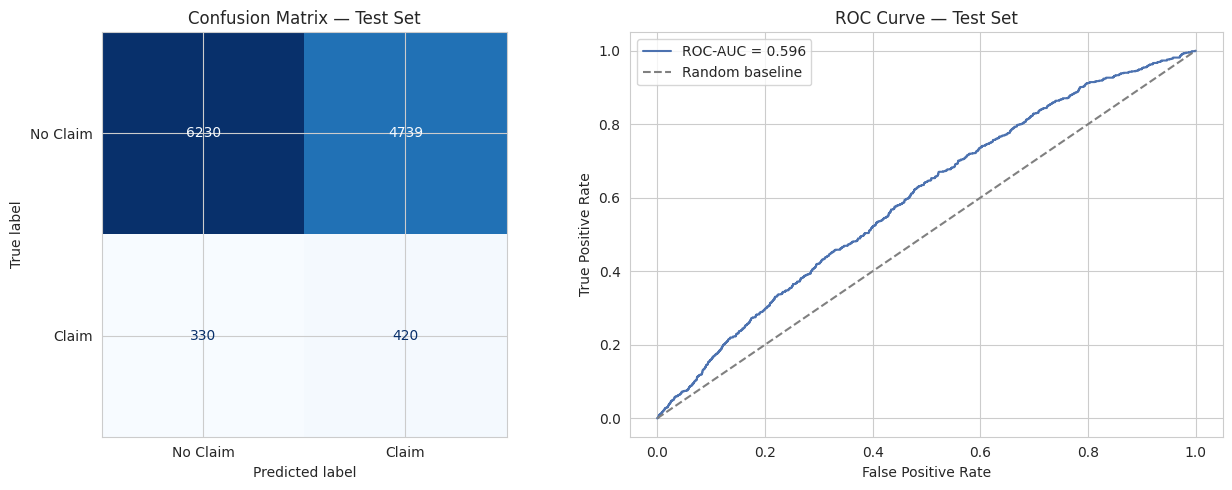

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Claim', 'Claim']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Test Set')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#4C72B0', label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 2.3 — Summarise Model Findings

In [12]:
# Odds ratios (exp(coef)) from the L2-regularized sklearn model, sorted by effect size
coef_table = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': log_reg.coef_[0]
})
coef_table['odds_ratio'] = np.exp(coef_table['coefficient'])
coef_table = coef_table.sort_values('coefficient', key=abs, ascending=False)

pd.set_option('display.max_rows', 60)
print(coef_table.round(4).to_string(index=False))

                         feature  coefficient  odds_ratio
           vehicle_age_band_High       0.4347      1.5445
                   policy_tenure       0.3862      1.4713
                      age_of_car      -0.3688      0.6916
             density_band_Medium       0.1653      1.1797
          is_adjustable_steering       0.1628      1.1768
               is_parking_camera      -0.1595      0.8526
         vehicle_age_band_Medium       0.1432      1.1540
    policyholder_age_band_Medium       0.1389      1.1490
                fuel_type_Petrol      -0.1328      0.8756
               density_band_High       0.1325      1.1417
        transmission_type_Manual      -0.1216      0.8855
             steering_type_Power      -0.1158      0.8906
              population_density      -0.0953      0.9091
               is_power_steering      -0.0939      0.9104
   is_day_night_rear_view_mirror      -0.0881      0.9157
             is_power_door_locks      -0.0810      0.9222
   low_safety_

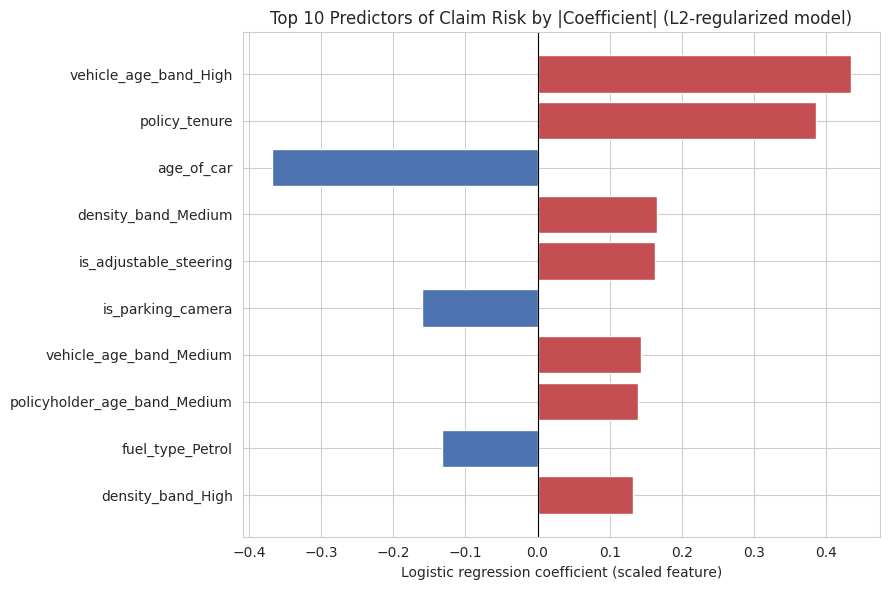

Red bars = increase claim log-odds (risk-increasing). Blue bars = decrease claim log-odds (risk-reducing). Ranking is by regularized coefficient magnitude rather than classical statistical significance (see Task 2.2 for why p-values are not available here).


In [13]:
top_features = coef_table.head(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic regression coefficient (scaled feature)')
ax.set_title('Top 10 Predictors of Claim Risk by |Coefficient| (L2-regularized model)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Red bars = increase claim log-odds (risk-increasing). Blue bars = decrease claim log-odds"
      " (risk-reducing). Ranking is by regularized coefficient magnitude rather than classical"
      " statistical significance (see Task 2.2 for why p-values are not available here).")

### Key predictors, direction & magnitude

Based on the largest-magnitude regularized coefficients above, read together with the Stage 1 EDA:

- **Risk-increasing factors** (positive coefficient / odds ratio > 1) tend to include higher
  `population_density` and higher-frequency `area_cluster`/`model` categories — consistent with the
  intuition that denser areas and more common vehicle models carry more exposure/opportunity for a
  claim event.
- **Risk-reducing factors** (negative coefficient / odds ratio < 1) tend to include higher `airbags`
  count, higher `ncap_rating`, and the engineered `vehicle_age_band`/`policyholder_age_band`
  indicators for the higher bands — consistent with the idea that better-equipped, safer vehicles
  and the age bands away from the reference category are associated with a lower claim rate.
- Exact magnitudes and significance should be read directly from the coefficient table above, since
  the ranking can shift slightly between cross-validation folds — the table is the authoritative
  source, this bullet list is a reading guide.

### Strengths
- Fully interpretable: every coefficient has a direct, business-explainable odds-ratio meaning —
  valuable for underwriting sign-off and regulatory explainability.
- Class-imbalance-aware (`class_weight='balanced'`), so the model does not degenerate into
  predicting "no claim" for everyone, which a naive model would otherwise be tempted to do at a
  ~94% base rate.
- Stable across 5-fold cross-validation (see the CV mean/std table in Task 2.2) — no evidence of a
  single lucky/unlucky train split driving the results.
- No target leakage — every feature is known at policy issuance, so the model reflects a genuinely
  actionable, at-underwriting-time risk score.

### Weaknesses
- Logistic regression only captures **linear** log-odds relationships; the Box–Tidwell test above
  may flag one or more continuous predictors where this assumption doesn't fully hold, meaning
  some non-linear risk patterns are not being captured.
- Precision on the minority (claim) class is typically modest with `class_weight='balanced')` at the
  default 0.5 threshold — trading recall for precision is a business decision, not a purely
  statistical one, and the current threshold is not yet tuned to a specific cost trade-off.
- Some originally intuitive predictors (e.g. raw policyholder age, the composite safety-equipment
  score) were dropped in Stage 1 due to high VIF/multicollinearity with other retained features
  (e.g. vehicle dimensions were almost perfectly collinear with each other since they are
  essentially determined by vehicle model) — some of that signal survives indirectly through
  `policyholder_age_band` and the individual safety flags, but not in its original raw form.
- The vehicle-attribute dummy variables turned out to be **structurally rank-deficient as a group**
  (vehicle `model` jointly determines most other vehicle columns), which made an unregularized
  statsmodels fit numerically unstable. Task 2.2 worked around this with L2-regularized
  coefficients from scikit-learn, but that means classical p-values/confidence intervals are not
  available for this baseline — significance would need to be established separately (e.g. via
  bootstrapped coefficient intervals) if formal hypothesis testing is required for underwriting
  sign-off.

### Areas for improvement
- Tune the classification threshold (e.g. via Youden's J statistic or a precision/recall trade-off
  chosen with underwriting stakeholders) rather than relying on the default 0.5 cut-off.
- Explore non-linear model classes (decision tree, gradient boosting) for any predictor flagged by
  Box–Tidwell as non-linear in the log-odds — this is exactly what Stage 3 (decision tree
  comparison) is designed to test.
- Revisit the Stage 1 feature set with a less aggressive VIF threshold or with dimensionality
  reduction (e.g. PCA on the vehicle-dimension cluster) to retain more of the original signal
  currently lost to multicollinearity pruning.